# Zongo Glacier: scaling velocity with stake data

In [11]:
### imports ###
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio

import matplotlib.pyplot as plt


Load data

In [13]:
# access data
zongo_fp = '/Users/albwel/Downloads/16_Zongo/'

# outline
outline_fp = 'Zongo_Outline-2006.shp'
outline_gdf = gpd.read_file(zongo_fp + outline_fp)

# load velocity rasters
vv_fp = 'Zongo_vel_2017-18.tif'
vx_fp = 'Zongo_velx_2017-18.tif'
vy_fp = 'Zongo_vely_2017-18.tif'

# load stake velocities
stake_fp = 'Velocity_comparison/zongo_stakes_vs_millan_vel.csv'
stake_df = pd.read_csv(zongo_fp + stake_fp, skipfooter=1, engine='python',
                       usecols=['stake', 'n_years', 'velocity_myr', 'altitude', 'stake_x', 'stake_y'])
stake_df


,stake,n_years,velocity_myr,altitude,stake_x,stake_y
0,12p,1,37.3130,4960.0000,592274.5490,8199936.484
1,11p,1,34.1980,4972.0000,592226.1635,8199893.990
2,13p,1,33.5410,4922.0000,592380.4780,8199948.646
3,18t,1,33.2070,5066.5220,591588.6900,8199979.115
4,6p,1,31.5650,5026.0000,591992.4685,8200012.269
5,4p,1,27.9730,5040.0000,591809.8930,8199808.799
6,8p,1,27.9690,5015.0000,592002.5290,8199784.606
7,21p,2,24.7400,5069.0410,591673.4593,8200047.288
8,x4,1,23.8310,5181.0550,591221.6630,8200248.866
9,5o,1,23.4510,5150.0000,591684.9235,8199975.010


Compare results

In [17]:
# coordinates to sample (x, y)
coords = list(zip(stake_df['stake_x'], stake_df['stake_y']))

# sample velocity magnitude
with rasterio.open(zongo_fp + vv_fp) as src:
    stake_df['vv'] = [v[0] for v in src.sample(coords)]

# sample x-component
with rasterio.open(zongo_fp + vx_fp) as src:
    stake_df['vx'] = [v[0] for v in src.sample(coords)]

# sample y-component
with rasterio.open(zongo_fp + vy_fp) as src:
    stake_df['vy'] = [v[0] for v in src.sample(coords)]

stake_df['vv_diff'] = stake_df['velocity_myr'] - stake_df['vv']
stake_df


,stake,n_years,velocity_myr,altitude,stake_x,stake_y,vv,vx,vy,vv_diff
0,12p,1,37.3130,4960.0000,592274.5490,8199936.484,2.056798,0.780043,-1.903142,35.256202
1,11p,1,34.1980,4972.0000,592226.1635,8199893.990,5.202161,5.125963,-0.887120,28.995839
2,13p,1,33.5410,4922.0000,592380.4780,8199948.646,1.046170,-0.043596,-1.045261,32.494830
3,18t,1,33.2070,5066.5220,591588.6900,8199979.115,10.607567,3.892714,-9.867484,22.599433
4,6p,1,31.5650,5026.0000,591992.4685,8200012.269,0.943400,0.485618,0.808813,30.621600
5,4p,1,27.9730,5040.0000,591809.8930,8199808.799,6.431166,4.384326,-4.705059,21.541834
6,8p,1,27.9690,5015.0000,592002.5290,8199784.606,5.779487,5.576502,-1.518252,22.189513
7,21p,2,24.7400,5069.0410,591673.4593,8200047.288,20.481298,12.274377,-16.395830,4.258702
8,x4,1,23.8310,5181.0550,591221.6630,8200248.866,14.965342,5.037151,-14.092145,8.865658
9,5o,1,23.4510,5150.0000,591684.9235,8199975.010,21.956657,13.165928,-17.571373,1.494343


Plot

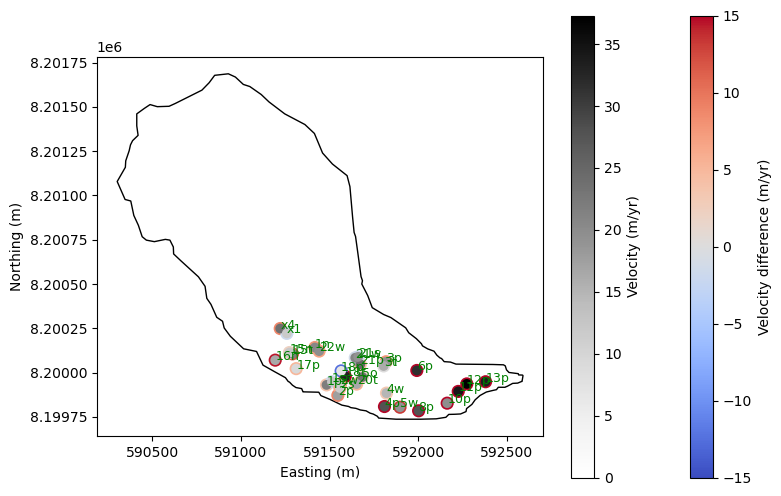

In [36]:
# plot to assess differences
fig, ax = plt.subplots(figsize=(9, 6))

outline_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
sc2 = ax.scatter(stake_df['stake_x'], stake_df['stake_y'], c=stake_df['vv_diff'], cmap='coolwarm', 
                 vmin=-15, vmax=15, s=90, edgecolor='none')
sc = ax.scatter(stake_df['stake_x'], stake_df['stake_y'], c=stake_df['velocity_myr'], cmap='Greys', vmin=0, s=50, edgecolor='none')

# add labels
for _, row in stake_df.iterrows():
    ax.text(row['stake_x'], row['stake_y'], row['stake'], fontsize=9, color='g')

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# colorbars
cbar2 = plt.colorbar(sc2, ax=ax)
cbar2.set_label('Velocity difference (m/yr)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Velocity (m/yr)')

ax.set_aspect('equal')
plt.show()
# RED vv_diff means Millan UNDERESTIMATES velocity. BLUE vv_diff means Millan OVERESTIMATES velocity


Remove some points and compare

In [55]:
# coordinates to sample (x, y)
stakes_remove = ['10p', '11p', '12p', '13p', '6p', '8p', '5w', '4p', '18t', '18p']
stake_rem_df = stake_df[~stake_df['stake'].isin(stakes_remove)]
print(f'Mean velocity difference with all stakes:\t{np.mean(stake_df["vv_diff"]):.1f} m/yr\n' + 
      f'Mean velocity difference with filtered stakes:\t{np.mean(stake_rem_df["vv_diff"]):.1f} m/yr\n' +
      f'Mean stake velocity:\t{np.mean(stake_rem_df["velocity_myr"]):.1f} m/yr')
stake_rem_df


Mean velocity difference with all stakes:	10.1 m/yr
Mean velocity difference with filtered stakes:	4.8 m/yr
 Mean stake velocity:	17.5 m/yr


,stake,n_years,velocity_myr,altitude,stake_x,stake_y,vv,vx,vy,vv_diff
7,21p,2,24.7400,5069.0410,591673.4593,8200047.288,20.481298,12.274377,-16.395830,4.258702
8,x4,1,23.8310,5181.0550,591221.6630,8200248.866,14.965342,5.037151,-14.092145,8.865658
9,5o,1,23.4510,5150.0000,591684.9235,8199975.010,21.956657,13.165928,-17.571373,1.494343
10,1p,1,21.7890,5079.0000,591482.9480,8199930.837,18.077497,-16.770208,6.749517,3.711503
11,15t,1,21.6970,5138.6320,591290.6760,8200106.003,10.006513,3.760708,-9.272938,11.690487
12,21w,2,21.0300,5097.7155,591645.0387,8200083.858,22.240982,11.766236,-18.873713,-1.210982
13,1n,2,20.5685,5121.0000,591417.4130,8200141.848,12.919042,5.393367,-11.739388,7.649458
14,22w,2,19.8215,5132.0085,591441.1903,8200121.546,12.919042,5.393367,-11.739388,6.902458
16,3p,2,19.1775,5040.9340,591818.8427,8200061.562,11.518162,7.138086,-9.039678,7.659338
17,21s,1,19.1610,5076.3020,591661.6290,8200089.094,21.050594,12.101658,-17.224327,-1.889594


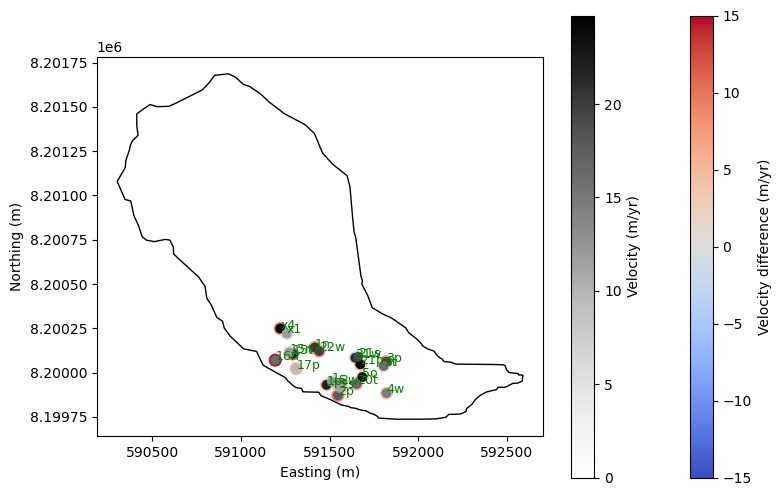

In [48]:
# plot to assess differences
fig, ax = plt.subplots(figsize=(9, 6))

outline_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
sc2 = ax.scatter(stake_rem_df['stake_x'], stake_rem_df['stake_y'], c=stake_rem_df['vv_diff'], cmap='coolwarm', 
                 vmin=-15, vmax=15, s=90, edgecolor='none')
sc = ax.scatter(stake_rem_df['stake_x'], stake_rem_df['stake_y'], c=stake_rem_df['velocity_myr'], 
                cmap='Greys', vmin=0, s=50, edgecolor='none')

# # add labels
# for _, row in stake_rem_df.iterrows():
#     ax.text(row['stake_x'], row['stake_y'], row['stake'], fontsize=9, color='g')

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')

# colorbars
cbar2 = plt.colorbar(sc2, ax=ax)
cbar2.set_label('Velocity difference (m/yr)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Velocity (m/yr)')

ax.set_aspect('equal')
plt.show()
# RED vv_diff means Millan UNDERESTIMATES velocity. BLUE vv_diff means Millan OVERESTIMATES velocity
